In [1]:
import torch
from check import setup_torch
# Dummy image-like data: batch=4, channels=1, height=256, width=256
data_dummy = torch.randn(4, 1, 256, 256, dtype=torch.float32)

device = setup_torch()
data_dummy.shape


✅ Using CUDA globally
GPU: NVIDIA GeForce RTX 4090


torch.Size([4, 1, 256, 256])

In [12]:
data_tensor = torch.load("../../json_data/dataset_updated.pt", map_location=device)
data_tensor = [t.flatten() for t in data_tensor]
data_tensor = [t.reshape((128,1000)) for t in data_tensor]
data_tensor = torch.stack(data_tensor)
data_tensor.shape

torch.Size([1532, 128, 1000])

In [3]:
from models.Data_Load import DataLoader_AutoEncoder, Dataset_

dataset = Dataset_(data_tensor,normalize=True)

train_size = 1200
test_size = len(dataset) - train_size
gen = torch.Generator(device=device)
train_dataset, test_dataset = torch.utils.data.random_split(
    dataset, [train_size, test_size], generator=gen
)

dataLoader = DataLoader_AutoEncoder(train_dataset, batch_size=40, shuffle=True)
dataLoader_test = DataLoader_AutoEncoder(test_dataset, batch_size=30, shuffle=False)

In [5]:
from models.Autencoder import AutoEncoder

latent_model = AutoEncoder()
latent_model.to(device)



Loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(latent_model.parameters(), lr=1e-3)
num_epochs = 150
for epoch in range(num_epochs):
    for batch in dataLoader:
        
        batch = batch.to(device)
        output = latent_model(batch)
        loss = Loss_fn(output, batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")


Epoch [1/150], Loss: 0.0357
Epoch [2/150], Loss: 0.0291
Epoch [3/150], Loss: 0.0266
Epoch [4/150], Loss: 0.0209
Epoch [5/150], Loss: 0.0111
Epoch [6/150], Loss: 0.0098
Epoch [7/150], Loss: 0.0068
Epoch [8/150], Loss: 0.0036
Epoch [9/150], Loss: 0.0034
Epoch [10/150], Loss: 0.0031
Epoch [11/150], Loss: 0.0024
Epoch [12/150], Loss: 0.0022
Epoch [13/150], Loss: 0.0030
Epoch [14/150], Loss: 0.0028
Epoch [15/150], Loss: 0.0023
Epoch [16/150], Loss: 0.0022
Epoch [17/150], Loss: 0.0017
Epoch [18/150], Loss: 0.0016
Epoch [19/150], Loss: 0.0017
Epoch [20/150], Loss: 0.0020
Epoch [21/150], Loss: 0.0014
Epoch [22/150], Loss: 0.0025
Epoch [23/150], Loss: 0.0016
Epoch [24/150], Loss: 0.0014
Epoch [25/150], Loss: 0.0031
Epoch [26/150], Loss: 0.0012
Epoch [27/150], Loss: 0.0018
Epoch [28/150], Loss: 0.0020
Epoch [29/150], Loss: 0.0023
Epoch [30/150], Loss: 0.0037
Epoch [31/150], Loss: 0.0011
Epoch [32/150], Loss: 0.0015
Epoch [33/150], Loss: 0.0018
Epoch [34/150], Loss: 0.0011
Epoch [35/150], Loss: 0

In [6]:

def test_model(model, dataLoader, Loss_fn, optimizer, num_epochs):

    model.eval()
    total_mse = 0.0
    total_mae = 0.0
    num_batches = 0

    output_data = []

    with torch.no_grad():
        for batch in dataLoader:
            batch = batch.to(device)
            output = model(batch)
            total_mse += Loss_fn(output, batch).item()
            total_mae += torch.mean(torch.abs(output - batch)).item()
            num_batches += 1
            output_data.append(output.cpu().numpy())
        

    avg_mse = total_mse / max(1, num_batches)
    avg_mae = total_mae / max(1, num_batches)
    return avg_mse,avg_mae

In [7]:
def plot_(X,Y,x_label='Index',y_label='Value',title='Output Data Plot'):
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 5))
    plt.plot(X, Y, marker='o')
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.grid()
    plt.show()

# Example usage:
# Assuming output_data is a list of numpy arrays, we can plot the first one

In [8]:
def train(epoch, lr_rate,dataLoader,Loss_fn, optimizer):
    from models.Autencoder import AutoEncoder

    latent_model = AutoEncoder()
    latent_model.to(device)


    if Loss_fn == "MSE":
        Loss_fn = torch.nn.MSELoss()
    elif Loss_fn == "MAE":
        Loss_fn = torch.nn.L1Loss()
    elif Loss_fn == "BCE":
        Loss_fn = torch.nn.BCEWithLogitsLoss()
    else:
        raise ValueError("Invalid Loss Function")
    if optimizer == "Adam":
        optimizer = torch.optim.Adam(latent_model.parameters(), lr=lr_rate )
    elif optimizer == "AdamW":
        optimizer = torch.optim.AdamW(latent_model.parameters(), lr=lr_rate )
    elif optimizer == "SGD":
        optimizer = torch.optim.SGD(latent_model.parameters(), lr=lr_rate )
    else:
        raise ValueError("Invalid Optimizer")
    num_epochs = epoch
    for epoch in range(num_epochs):
        for batch in dataLoader:
            
            batch = batch.to(device)
            output = latent_model(batch)
            loss = Loss_fn(output, batch)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")
    return latent_model, Loss_fn, optimizer, num_epochs


In [14]:
lr_rate_list = [4e-3,5e-3,1e-2,2e-2,4e-2,5e-2] 
Loss_fn_list = ["MSE", "MAE", "BCE"]
optimizer_list = ["Adam"]

output_mse = {}
output_mae = {}
epoch = 150

for lr_rate in lr_rate_list:
    for Loss_ in Loss_fn_list:
        for optimizer_ in optimizer_list:
            print(f"Training with learning rate: {lr_rate}, Loss Function: {Loss_}, Optimizer: {optimizer_}")
            latent_model, Loss_fn, optimizer, num_epochs = train(epoch, lr_rate, dataLoader, Loss_, optimizer_  )
            avg_loss, avg_mae = test_model(latent_model, dataLoader_test, Loss_fn, optimizer, num_epochs)
            if f"{Loss_}_{optimizer_}" not in output_mse:
                output_mse[f"{Loss_}_{optimizer_}"] = []
            output_mse[f"{Loss_}_{optimizer_}"].append(avg_loss)


Training with learning rate: 0.004, Loss Function: MSE, Optimizer: Adam
Epoch [1/150], Loss: 0.0481
Epoch [2/150], Loss: 0.0326
Epoch [3/150], Loss: 0.0099
Epoch [4/150], Loss: 0.0066
Epoch [5/150], Loss: 0.0062
Epoch [6/150], Loss: 0.0058
Epoch [7/150], Loss: 0.0047
Epoch [8/150], Loss: 0.0045
Epoch [9/150], Loss: 0.0034
Epoch [10/150], Loss: 0.0038
Epoch [11/150], Loss: 0.0039
Epoch [12/150], Loss: 0.0025
Epoch [13/150], Loss: 0.0026
Epoch [14/150], Loss: 0.0021
Epoch [15/150], Loss: 0.0026
Epoch [16/150], Loss: 0.0022
Epoch [17/150], Loss: 0.0060
Epoch [18/150], Loss: 0.0015
Epoch [19/150], Loss: 0.0029
Epoch [20/150], Loss: 0.0031
Epoch [21/150], Loss: 0.0016
Epoch [22/150], Loss: 0.0025
Epoch [23/150], Loss: 0.0023
Epoch [24/150], Loss: 0.0014
Epoch [25/150], Loss: 0.0013
Epoch [26/150], Loss: 0.0013
Epoch [27/150], Loss: 0.0017
Epoch [28/150], Loss: 0.0013
Epoch [29/150], Loss: 0.0011
Epoch [30/150], Loss: 0.0018
Epoch [31/150], Loss: 0.0012
Epoch [32/150], Loss: 0.0015
Epoch [33

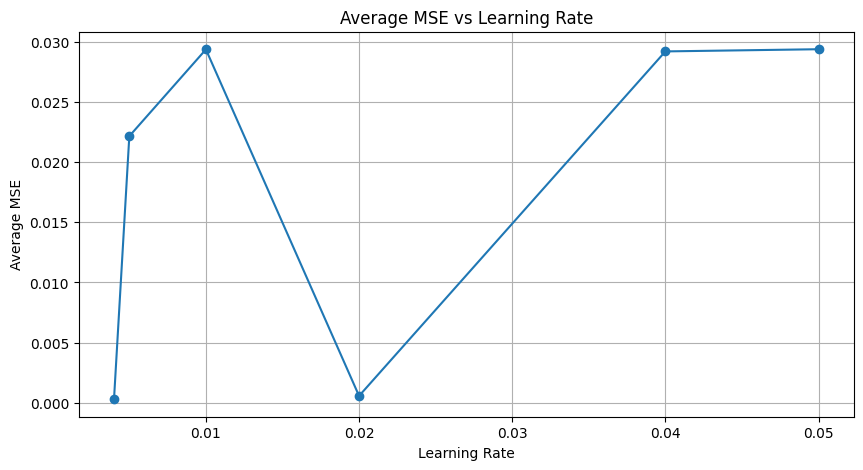

In [15]:
plot_(lr_rate_list, output_mse["MSE_Adam"], x_label='Learning Rate', y_label='Average MSE', title='Average MSE vs Learning Rate')


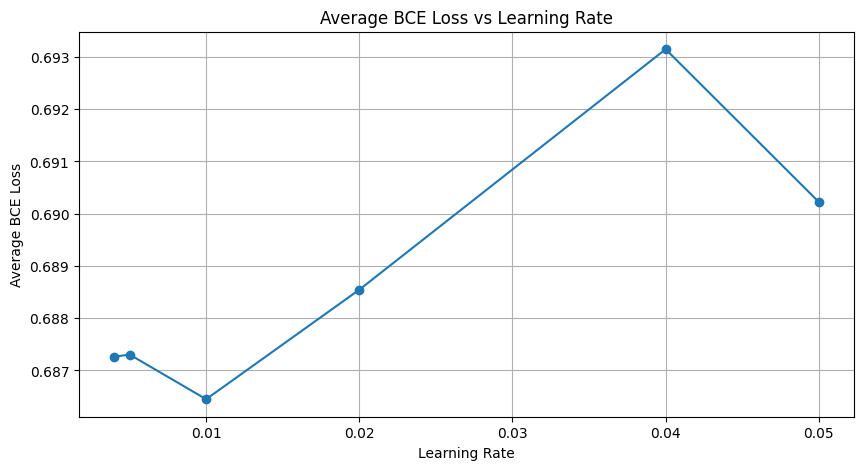

In [16]:
plot_(lr_rate_list, output_mse["BCE_Adam"], x_label='Learning Rate', y_label='Average BCE Loss', title='Average BCE Loss vs Learning Rate')


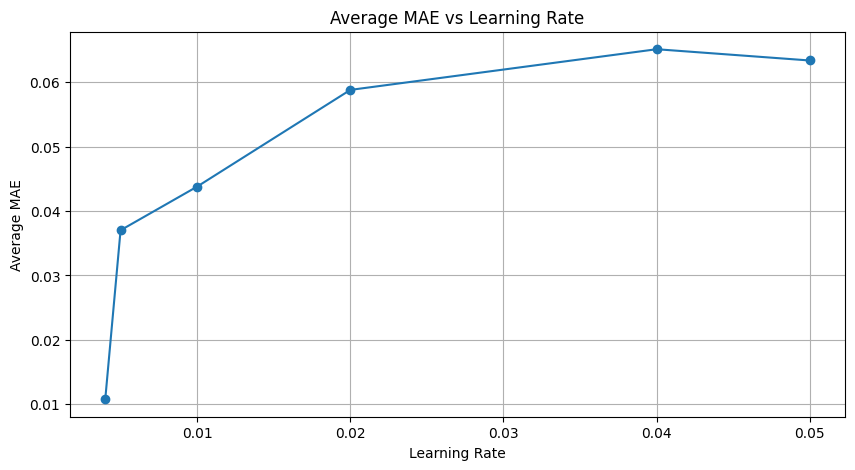

In [17]:
plot_(lr_rate_list, output_mse["MAE_Adam"], x_label='Learning Rate', y_label='Average MAE', title='Average MAE vs Learning Rate')


### LR choice
We can therefore see that the best lr would be 0.005-0.02 this would thus be our choice for the model

In [18]:
lr_rate = 0.02
epoch = 300
latent_model, Loss_fn, optimizer, num_epochs = train(epoch, lr_rate, dataLoader,Loss_fn="MSE", optimizer="Adam")



Epoch [1/300], Loss: 0.0575
Epoch [2/300], Loss: 0.0231
Epoch [3/300], Loss: 0.0101
Epoch [4/300], Loss: 0.0085
Epoch [5/300], Loss: 0.0073
Epoch [6/300], Loss: 0.0075
Epoch [7/300], Loss: 0.0059
Epoch [8/300], Loss: 0.0057
Epoch [9/300], Loss: 0.0048
Epoch [10/300], Loss: 0.0048
Epoch [11/300], Loss: 0.0040
Epoch [12/300], Loss: 0.0036
Epoch [13/300], Loss: 0.0040
Epoch [14/300], Loss: 0.0042
Epoch [15/300], Loss: 0.0032
Epoch [16/300], Loss: 0.0033
Epoch [17/300], Loss: 0.0057
Epoch [18/300], Loss: 0.0074
Epoch [19/300], Loss: 0.0051
Epoch [20/300], Loss: 0.0049
Epoch [21/300], Loss: 0.0030
Epoch [22/300], Loss: 0.0027
Epoch [23/300], Loss: 0.0033
Epoch [24/300], Loss: 0.0025
Epoch [25/300], Loss: 0.0023
Epoch [26/300], Loss: 0.0037
Epoch [27/300], Loss: 0.0032
Epoch [28/300], Loss: 0.0018
Epoch [29/300], Loss: 0.0027
Epoch [30/300], Loss: 0.0025
Epoch [31/300], Loss: 0.0018
Epoch [32/300], Loss: 0.0018
Epoch [33/300], Loss: 0.0018
Epoch [34/300], Loss: 0.0017
Epoch [35/300], Loss: 0

In [19]:
from matplotlib import pyplot as plt
import matplotlib as mpl


data1 = dataLoader.dataset[0][0]
data1_latent = latent_model.encode_latent(dataLoader.dataset[0].unsqueeze(0))
data_reconstructed = latent_model.decode_latent(data1_latent)[0][0]
data1_latent.shape, data1.shape,data_reconstructed.shape


(torch.Size([1, 128, 16, 125]),
 torch.Size([128, 1000]),
 torch.Size([128, 1000]))

(torch.Size([128, 1000]), torch.Size([128, 1000]))

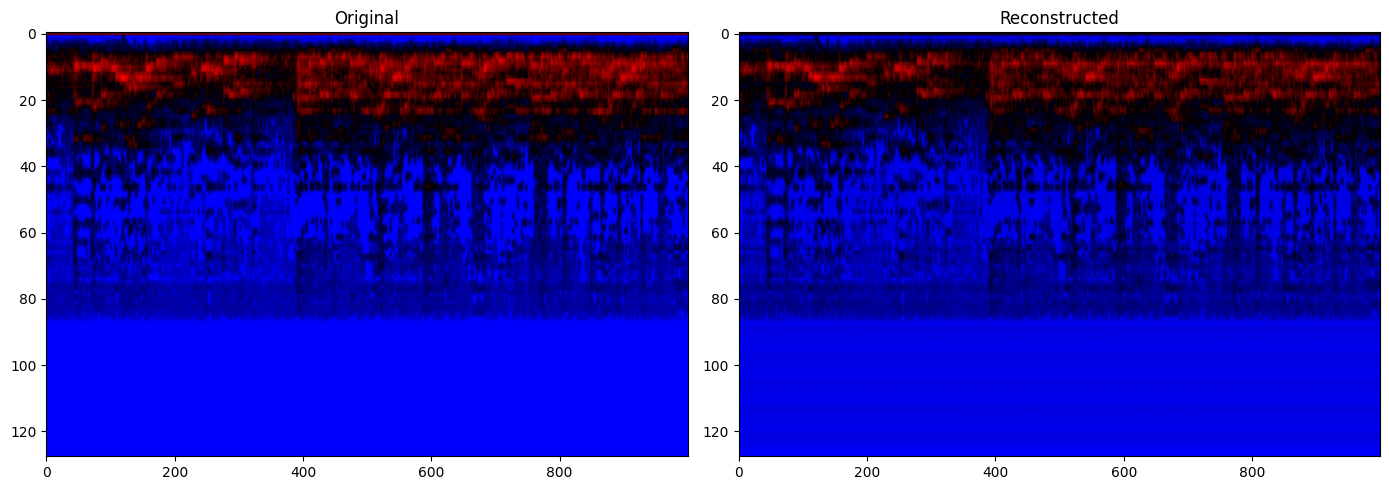

In [ ]:
data1_cpu = data1.detach().cpu()
data_reconstructed_cpu = data_reconstructed.detach().cpu()
cmap = cmap2 = mpl.colors.LinearSegmentedColormap.from_list('my_colormap', ['blue', 'black', 'red'], 256)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(data1_cpu, cmap=cmap, aspect='auto')
axes[0].set_title('Original')
axes[1].imshow(data_reconstructed_cpu, cmap=cmap, aspect='auto')
axes[1].set_title('Reconstructed')
plt.tight_layout()
data1_cpu.shape, data_reconstructed_cpu.shape

Epoch [1/300], Loss: 0.0229
Epoch [2/300], Loss: 0.0191
Epoch [3/300], Loss: 0.0147
Epoch [4/300], Loss: 0.0103
Epoch [5/300], Loss: 0.0096
Epoch [6/300], Loss: 0.0099
Epoch [7/300], Loss: 0.0085
Epoch [8/300], Loss: 0.0069
Epoch [9/300], Loss: 0.0067
Epoch [10/300], Loss: 0.0053
Epoch [11/300], Loss: 0.0043
Epoch [12/300], Loss: 0.0042
Epoch [13/300], Loss: 0.0047
Epoch [14/300], Loss: 0.0034
Epoch [15/300], Loss: 0.0035
Epoch [16/300], Loss: 0.0036
Epoch [17/300], Loss: 0.0033
Epoch [18/300], Loss: 0.0039
Epoch [19/300], Loss: 0.0028
Epoch [20/300], Loss: 0.0064
Epoch [21/300], Loss: 0.0033
Epoch [22/300], Loss: 0.0037
Epoch [23/300], Loss: 0.0024
Epoch [24/300], Loss: 0.0024
Epoch [25/300], Loss: 0.0038
Epoch [26/300], Loss: 0.0024
Epoch [27/300], Loss: 0.0025
Epoch [28/300], Loss: 0.0018
Epoch [29/300], Loss: 0.0021
Epoch [30/300], Loss: 0.0034
Epoch [31/300], Loss: 0.0024
Epoch [32/300], Loss: 0.0027
Epoch [33/300], Loss: 0.0034
Epoch [34/300], Loss: 0.0017
Epoch [35/300], Loss: 0

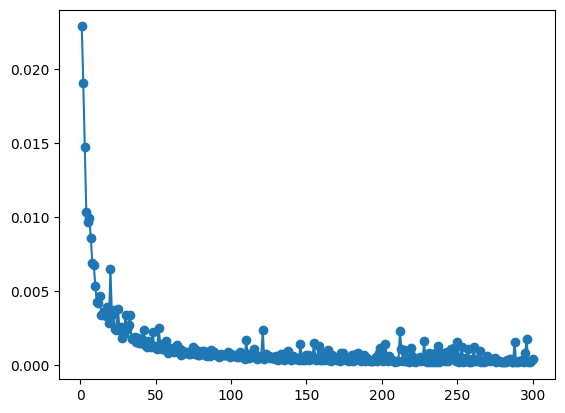

In [24]:
epoch = 300
epochs = list(range(1, epoch + 1))
loss_values = []
latent_model_test_epoch = AutoEncoder()
optimizer = torch.optim.Adam(latent_model_test_epoch.parameters(), lr=0.02)
Loss_fn = torch.nn.MSELoss()

for epoch in range(num_epochs):
    for batch in dataLoader:
        
        batch = batch.to(device)
        output = latent_model_test_epoch(batch)
        loss = Loss_fn(output, batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    loss_values.append(loss.item())
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")
plt.plot(epochs, loss_values, marker='o')

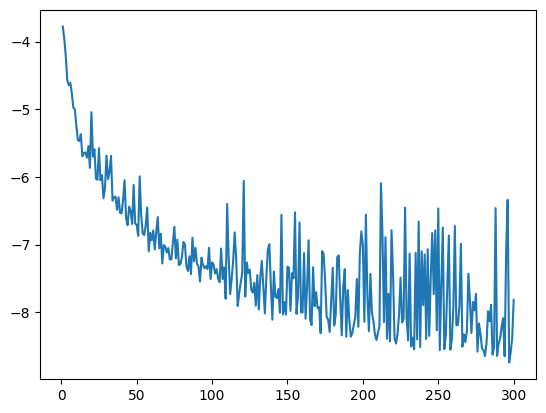

In [33]:
import numpy as np

log_val = np.log(loss_values)

plt.plot(epochs,log_val)